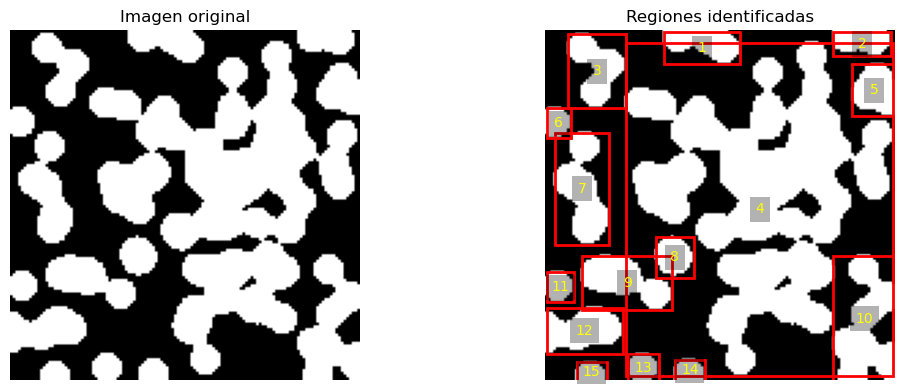

In [1]:
import numpy as np
from skimage import measure, data
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Cargar imagen de ejemplo (blobs binarios)
image = data.binary_blobs(length=128, blob_size_fraction=0.1, n_dim=2)

# Etiquetar los componentes conectados en la imagen binaria
labeled_image = measure.label(image)

# Medir propiedades de cada región
props = measure.regionprops(labeled_image)

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mostrar imagen original
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Imagen original")
axes[0].axis('off')

# Mostrar imagen con regiones y bounding boxes
axes[1].imshow(image, cmap='gray')
axes[1].set_title("Regiones identificadas")
axes[1].axis('off')

# Dibujar bounding box y número de región
for i, region in enumerate(props, start=1):
    minr, minc, maxr, maxc = region.bbox
    # Rectángulo del bounding box
    rect = patches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                             fill=False, edgecolor='red', linewidth=2)
    axes[1].add_patch(rect)
    # Número de región (posición en el centro del bounding box)
    axes[1].text(minc + (maxc - minc)/2, minr + (maxr - minr)/2, 
                 str(i), color='yellow', fontsize=10, ha='center', va='center',
                 bbox=dict(facecolor='black', alpha=0.3, edgecolor='none'))

plt.tight_layout()
plt.show()


In [2]:

# Accessing properties of a specific region (e.g., the first region)
if props: # Check if any regions were found
    first_region = props[0]
    print(f"Area of the first region: {first_region.area}")
    print(f"Centroid of the first region: {first_region.centroid}")
    print(f"Bounding box of the first region: {first_region.bbox}") # (min_row, min_col, max_row, max_col)
    print(f"Equivalent diameter of the first region: {first_region.equivalent_diameter}")

# Iterating through all regions and printing selected properties
print("\nProperties of all regions:")
for i, region in enumerate(props):
    print(f"Region {i+1}:")
    print(f"  Label: {region.label}")
    print(f"  Area: {region.area}")
    print(f"  Centroid: {region.centroid}")
    print(f"  Perimeter: {region.perimeter}")
    print(f"  Eccentricity: {region.eccentricity}")

Area of the first region: 237.0
Centroid of the first region: (4.29535864978903, 57.59493670886076)
Bounding box of the first region: (0, 43, 12, 71)
Equivalent diameter of the first region: 17.371176474327626

Properties of all regions:
Region 1:
  Label: 1
  Area: 237.0
  Centroid: (4.29535864978903, 57.59493670886076)
  Perimeter: 69.45584412271572
  Eccentricity: 0.9400965038501358
Region 2:
  Label: 2
  Area: 163.0
  Centroid: (3.4907975460122698, 115.20858895705521)
  Perimeter: 52.72792206135785
  Eccentricity: 0.9165708734410831
Region 3:
  Label: 3
  Area: 309.0
  Centroid: (13.300970873786408, 18.06148867313916)
  Perimeter: 83.25483399593904
  Eccentricity: 0.7855042116635945
Region 4:
  Label: 4
  Area: 4882.0
  Centroid: (59.255428103236376, 79.54956984842278)
  Perimeter: 885.1696603029501
  Eccentricity: 0.5829217441221837
Region 5:
  Label: 5
  Area: 235.0
  Centroid: (21.33191489361702, 120.34468085106383)
  Perimeter: 57.21320343559643
  Eccentricity: 0.49970844781058